In [12]:
%load_ext autoreload
%autoreload 2

# Plotting code for figures in paper

In [13]:
import sys
sys.path.append('../')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import constants as sconstants

import h5py
import json
from pathlib import Path

## Efficiency Plot (Fig. 2)

In [ ]:
FILE_NAME = '../release/luhdm_datarelease_v10_A_f1_atm.h5'
f = h5py.File(FILE_NAME, "r")

q_efficiency = f['detector']['q_gev_1'][:]
q_efficiency = np.insert(q_efficiency, [0,400], [30, 1e5])  # Post-processing to include endpoints

efficiency = f['detector']['eff_1_df3'][:]
efficiency = np.insert(efficiency, [0, 400], [0, 1])  # Post-processing to include endpoints

cands = f['detector']['events_mode1'][:]

GEV2TEV = 1e-3

(-0.05, 1.1)

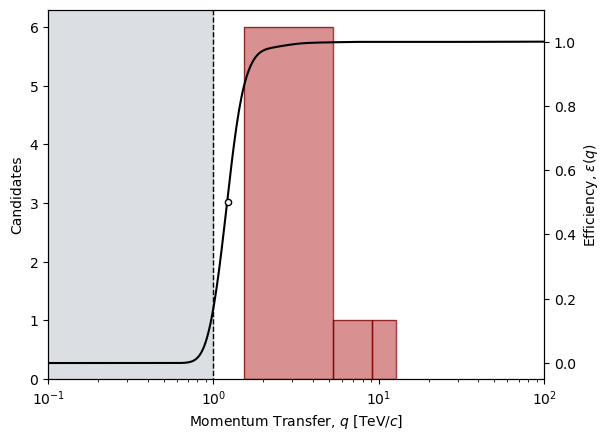

In [ ]:
fig, ax1 = plt.subplots(1, 1)

# ─── CANDIDATES ─── #
ax1.hist(cands*GEV2TEV, bins=3, facecolor='firebrick', alpha=0.5, edgecolor='None')
ax1.hist(cands*GEV2TEV, bins=3, facecolor='None', alpha=0.75, edgecolor='maroon', lw=1)
ax1.set_xscale('log')
ax1.set_xlim(1e-1, 1e2)
ax1.set_xlabel(r'Momentum Transfer, $q~[\mathrm{TeV}/c]$')
ax1.set_ylabel('Candidates')

# ─── Efficiency ─── #
ax2 = ax1.twinx()
ax2.plot(q_efficiency*GEV2TEV, efficiency, color='black')
ax2.set_ylabel(r'Efficiency, $\varepsilon(q)$')
# ax2.scatter(q_efficiency[np.argwhere(efficiency >= 0.5)[0]]*GEV2TEV, 0.5, marker='o', fc='w', edgecolor='black', s=20, zorder=10)
ax2.scatter(q_efficiency[np.argwhere(efficiency >= 0.5)[0]]*GEV2TEV, 0.5, marker='o', fc='w', edgecolor='black', s=20, zorder=10)
ax2.axvspan(30*GEV2TEV, 1e3*GEV2TEV, color='slategrey', alpha=0.25, zorder=0, lw=1)
# ax2.vlines(q_efficiency[np.argwhere(efficiency >= 0.5)[0]]*GEV2TEV, -0.2, 1.5, color='black', ls='--', lw=1)
ax2.vlines(1e3*GEV2TEV, -0.2, 1.5, color='black', ls='--', lw=1)
ax2.set_ylim(-0.05, 1.1)

## Limit Plot (Fig. 3)

In [10]:
def conv_m2pGeV(meter):
    return 5.0679e6 * meter * 1e9

def reduced_mass(m1, m2):
    return m1 * m2 / (m1 + m2)

def q_ref(m_DM):    
    mu_chi_n = reduced_mass(m_DM, U_GEV)  # Reduced mass of DM and nucleon
    return mu_chi_n * V_0

def compute_alpha_n(g_n, g_d, m_DM, m_d):
    N_d = m_DM / m_d
    return N_d * g_d * g_n / (4 * np.pi)

def cross_section(g_n, g_d, m_DM, m_d):
    alpha = compute_alpha_n(g_n, g_d, m_DM, m_d)
    q = q_ref(m_DM)
    return 4 * np.pi * alpha**2 / q**4 * reduced_mass(m_DM, U_GEV)**2 / conv_m2pGeV(1)**2 * 1e4 # Convert to cm^2

def cross_section_n(alpha_n, m_DM):
    q = q_ref(m_DM)
    return 4 * np.pi * alpha_n**2 / q**4 * reduced_mass(m_DM, U_GEV)**2 / conv_m2pGeV(1)**2 * 1e4 # Convert to cm^2

def g_lim(alpha_tilde):
    
    return np.sqrt(16 * np.pi * U_GEV**2 / M_PL**2 * alpha_tilde)

V_0 = 1e-3
U_GEV = 0.931  # Atomic mass unit in GeV
ALPHA_US_20 = 20
M_PL = sconstants.physical_constants['Planck mass'][0] * sconstants.c**2 / sconstants.electron_volt / 1e9  # Planck mass in GeV
G_20 = g_lim(ALPHA_US_20)
G_D = 1  # Assumed dark coupling
M_D = 1e-6  # Constituent mass in GeV


In [11]:
# Existing Constraints
mass_carney, alpha_carney = np.loadtxt('../data/2007.12067/massless_limit.txt', unpack=True)  # Carney et al. 2007.12067
mass_moore, alpha_moore = np.loadtxt('../data/2508.00815/massless_limit.txt', unpack=True)  # Carney et al. 2007.12067

<Figure size 640x480 with 0 Axes>

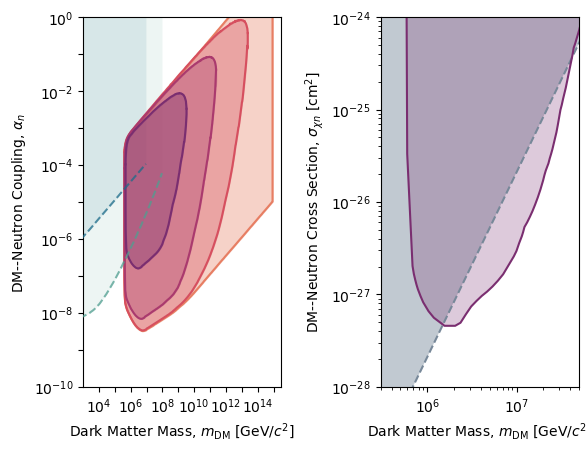

In [18]:
plt.figure()

# ─── ax[0] ─── #
CONTOURS = Path("../release/luhdm_contours_v10_A_f1_atm.json")

DOC = json.loads(CONTOURS.read_text())

colors_existing = sns.color_palette('crest', n_colors=2)
colors = sns.color_palette('flare', n_colors=4)
alpha_existing_fill = 0.1
alpha_existing_line = 0.75
alpha_lim = 0.35
zorders = [2.2, 2.3, 2.4, 2.5]

fig, ax = plt.subplots(1, 2)

# Existing
ax[0].loglog(mass_carney, alpha_carney, color=colors_existing[0], linestyle='--', alpha=alpha_existing_line, zorder=2.6)
ax[0].fill_between(mass_carney, alpha_carney, 1e0, color=colors_existing[0], alpha=alpha_existing_fill, lw=0)
ax[0].loglog(mass_moore, alpha_moore, color=colors_existing[1], linestyle='--', alpha=alpha_existing_line, zorder=2.6)
ax[0].fill_between(mass_moore, alpha_moore, 1e0, color=colors_existing[1], alpha=alpha_existing_fill, lw=0)

# Us
for ikey, key in enumerate(DOC['surfaces'].keys()):
    REFINED = DOC['surfaces'][key]
    ms = np.array(REFINED['mass_gev'])
    alphas_floor = np.array(REFINED['floor_alpha_n'])
    alphas_ceiling = np.array(REFINED['ceiling_alpha_n'])
    alphas_floor_fix = np.insert(alphas_floor, 0, alphas_ceiling[0])
    ms_floor_fix = np.insert(ms, 0, ms[0])

    if key == 'massless_f1':
        alphas_floor_fix = np.insert(alphas_floor_fix, 166, 1.1)
        ms_floor_fix = np.insert(ms_floor_fix, -1, ms[-1])
        alphas_ceiling = np.array([1.1 if x is None else x for x in alphas_ceiling])
        argmin = np.argmin(alphas_floor)

    elif key == '200um_f1':
        alphas_floor_fix = np.insert(alphas_floor_fix[0:-3], len(alphas_floor_fix)-3, alphas_ceiling[-1])
        ms_floor_fix = np.insert(ms_floor_fix[0:-3], len(ms_floor_fix)-3, ms[-1])

    else:
        alphas_floor_fix = np.insert(alphas_floor_fix, len(alphas_floor_fix), alphas_ceiling[-1])
        ms_floor_fix = np.insert(ms_floor_fix, -1, ms[-1])

    ax[0].loglog(ms_floor_fix, alphas_floor_fix, color=colors[ikey], zorder=zorders[ikey])
    ax[0].loglog(ms, alphas_ceiling, color=colors[ikey], zorder=zorders[ikey])
    ax[0].fill_between(ms, alphas_floor, alphas_ceiling, color=colors[ikey], alpha=alpha_lim, zorder=zorders[ikey]-0.1)
    
        
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[0].set_xlim(1e3, 3e15)
ax[0].set_ylim(1e-10, 1e0)
ax[0].set_yticks([1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0])
ax[0].set_yticklabels(['$10^{-10}$', '', '$10^{-8}$', '', '$10^{-6}$', '', '$10^{-4}$', '', '$10^{-2}$', '', '$10^{0}$'])
ax[0].set_xticks([1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11, 1e12, 1e13, 1e14, 1e15])
ax[0].set_xticklabels(['$10^{4}$', '', '$10^{6}$', '', '$10^{8}$', '', '$10^{10}$', '', '$10^{12}$', '', '$10^{14}$', ''])

ax[0].set_xlabel('Dark Matter Mass, $m_\mathrm{DM}~[\mathrm{GeV}/c^2]$')
ax[0].set_ylabel(r'DM--Neutron Coupling, $\alpha_n$')


# ─── ax[1] ─── #
CONTOUR = Path("../release/luhdm_contours_v10_B_f0p1_noatm.json")
DOC = json.loads(CONTOUR.read_text())

color_lim = colors[-1]
color_fifth = 'lightslategrey'

# Existing
m_dms = np.logspace(5, 8, 100)
css = cross_section(G_20, G_D, m_dms, M_D)

# Us
REFINED = DOC['surfaces']['20um_f0p1_noatm']
ms = np.array(REFINED['mass_gev'])
alphas_floor = np.array(REFINED['floor_alpha_n'])
alphas_ceiling = np.array(REFINED['ceiling_alpha_n'])
alphas_floor_fix = np.insert(alphas_floor, 0, alphas_ceiling[0])
ms_floor_fix = np.insert(ms, 0, ms[0])

css_us = cross_section_n(alphas_floor_fix, ms_floor_fix)
ax[1].fill_between(m_dms, css, 1e-24, color=color_fifth, alpha=0.45, lw=0)
ax[1].loglog(m_dms, css, color=color_fifth, alpha=1, ls='--')
ax[1].fill_between(ms_floor_fix, css_us, 1e-24, color=color_lim, alpha=0.25, lw=0)
ax[1].loglog(ms_floor_fix, css_us, color=color_lim, ls='-')
ax[1].set_xlim(3e5, 5e7)
ax[1].set_ylim(1e-28, 1e-24)

ax[1].set_xlabel('Dark Matter Mass, $m_\mathrm{DM}~[\mathrm{GeV}/c^2]$')
ax[1].set_ylabel(r'DM--Neutron Cross Section, $\sigma_{\chi n}~[\mathrm{cm^{2}}]$')

plt.subplots_adjust(wspace=0.5)

# SM Plots

## PDF Plot (Fig. 4)

In [28]:
from luhdm import halo, atmosphere

In [29]:
# NEEDS FIXING TO PRODUCE SHM VALUES WITH NON-ZERO V_E!
M_DM = 1e8

alphas_traj = np.array([1e-4, 1.5e-3, 1.5e-3])
lambs_traj = np.array([1, 1e-6, 1])
al_traj = zip(alphas_traj, lambs_traj)

vs_test = np.linspace(1e-6, 1e-2, 1000)

counts_arr = np.zeros((3, 20))
bin_edges_arr = np.zeros((3, 21))
bin_centres_arr = np.zeros((3, 20))
f_v_f_test_list = []

v_i_samples = atmosphere.sample_shm(int(1e6))

i = 0
v_min = 1e-7
for alpha_traj, lamb_traj in al_traj:
    v_f_samples = atmosphere.compute_v_f_distribution(alpha_traj, lamb_traj, M_DM, v_i_samples, v_min=v_min) 
    f_v_f_test, f_survive = atmosphere.compute_f_vf(v_f_samples, v_floor=v_min)

    counts, bin_edges = np.histogram(v_f_samples, bins=20, density=True)
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_centres_arr[i] = bin_centres
    bin_edges_arr[i] = bin_edges
    counts_arr[i] = counts
    f_v_f_test_list.append(f_v_f_test)
    i+=1

Text(0, 0.5, 'PDF, $f_\\mathrm{det}(v/c)$')

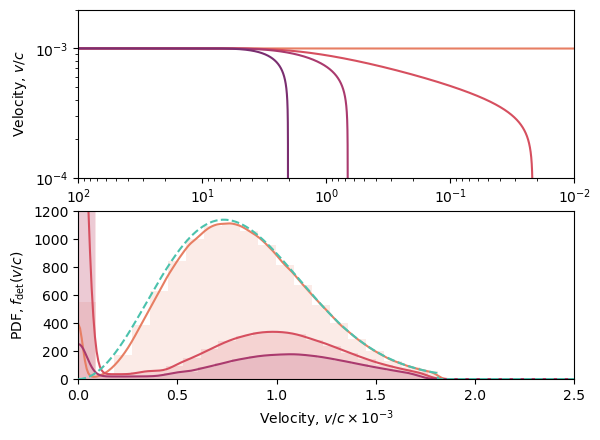

In [30]:
colors = sns.color_palette('flare', n_colors=4)

z_eval = np.geomspace(200, 1e-2, 100000) * atmosphere.H
alphas_traj = np.array([1e-4, 1.5e-3, 1.5e-3, 3e-3])
lambs_traj = np.array([1, 1e-6, 1, 1])
al_traj = zip(alphas_traj, lambs_traj)

fig, ax = plt.subplots(2, 1)

V_I = 1e-3
i = 0
for alpha_traj, lamb_traj in al_traj:
    zs, vs, _ = atmosphere.solve_ode(V_I, alpha_traj, lamb_traj, M_DM, atmosphere.M_MOL, v_min=1e-10, h_max=200*atmosphere.H, z_eval=z_eval)
    ax[0].plot(zs/atmosphere.H, vs/sconstants.c, color=colors[i])
    i+=1

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[0].set_xlim(1e-2, 1e2)
ax[0].set_ylim(1e-4, 2e-3)

ax[0].invert_xaxis()

ax[0].set_xlabel('Height, $z / h_0$')
ax[0].set_ylabel('Velocity, $v / c$')

# ax[0].text(1.25e-2, 1.1e-3, r'$\alpha_n = 10^{-4}$', ha='right', color=colors[0], fontsize=8)
# ax[0].text(3e-2, 4.2e-4, r'$\alpha_n = 1.5\times 10^{-3}$', ha='right', color=colors[1], fontsize=8, rotation=-35)
# ax[0].text(8e-2, 3.9e-4, r'$\lambda = 1\,\mathrm{\mu m}$', ha='right', color=colors[1], fontsize=8, rotation=-35)
# ax[0].text(6e-1, 1.2e-4, r'$\alpha_n = 1.5\times10^{-3}$', color=colors[2], fontsize=8, rotation=-90)
# ax[0].text(1.8, 1.2e-4, r'$\alpha_n = 3\times10^{-3}$', color=colors[3], fontsize=8, rotation=-90)

# ax[0].text(1.25e-2, 1.5e-3, 'Atmosphere', fontsize=8, ha='right', color='white')
# ax[0].text(3.75e0, 1.5e-3, r'$m_\mathrm{DM} = 10^8\,\mathrm{GeV}$', fontsize=8, ha='right', color='k')

# ─── AX[1] ───
alpha_dist = 0.15
color_shm = sns.color_palette('mako', n_colors=3)[-1]
colors_dist = sns.color_palette('flare', n_colors=3)
vs_test = np.linspace(1e-6, 2.5e-3, 300)
for i in range(3):
    ax[1].bar(bin_centres_arr[i]*1e3, counts_arr[i], width=np.diff(bin_edges_arr[i]*1e3), color=colors[i], alpha=alpha_dist)
    ax[1].plot(vs_test*1e3, f_v_f_test_list[i](vs_test), color=colors[i], zorder=2.5)

plt.plot(vs_test*1e3, halo.standard_halo_model(vs_test), color=color_shm, ls='--', zorder=2.7)

ax[1].set_xlim(0, 0.0025*1e3)
ax[1].set_ylim(0, 1200)

ax[1].set_xlabel(r'Velocity, $v/c \times 10^{-3}$')
ax[1].set_ylabel(r'PDF, $f_\mathrm{det}(v/c)$')

## Rate Plot (Fig. 5)

In [30]:
from luhdm import halo, config, atmosphere, rate, units

In [32]:
FILE_NAME = '../release/luhdm_datarelease_v10_A_f1_atm.h5'
f = h5py.File(FILE_NAME, "r")
dat = f['results/extremeness']

In [ ]:
def generate_f_v(alpha_n, lamb, m_dm):
    # 1. draw initial speeds at the top of the atmosphere (SHM)
    np.random.seed(42)
    v_i_samples = atmosphere.sample_shm(int(3e6))

# 2. push each sample through the energy-loss ODE down to ground level
    v_min = config.Q_THRESH / m_dm / 1000   # detector threshold speed, same convention as elsewhere
    v_f_samples = atmosphere.compute_v_f_distribution(
    alpha_n, lamb, m_dm, v_i_samples, v_min=v_min
)

# 3. build the attenuated distribution (KDE) + survival fraction
    f_v_f, F_survive = atmosphere.compute_f_vf(v_f_samples, v_min)
    
    return f_v_f

GEV2TEV = 1e-3

m_dms = [3e5, 1e8, 1e8, 1e8]
alpha_ns = [1e-5, 1e-5, 3.863e-3, 1e-5]
lambs = [None, None, None, 196e-6]

qs = np.logspace(1, 6, 500)
rates_arr = np.zeros((len(m_dms), len(qs)))

In [36]:
# Generate Rates
for i in range(len(m_dms)):
    alpha_n = alpha_ns[i]
    lamb = lambs[i]
    m_dm = m_dms[i]
    print(alpha_n, lamb, m_dm)

    if lamb is None:
        f_v_f = generate_f_v(alpha_n, 1e-2, m_dm)
    else:
        f_v_f = generate_f_v(alpha_n, lamb, m_dm)
    
    xs = rate.make_xsec(lamb)
    rates = rate.differential_rate_trapz(qs, alpha_n, m_dm, f_v_f, xs)
    rates_arr[i, :] = rates

1e-05 None 300000.0
1e-05 None 100000000.0
0.003863 None 100000000.0
1e-05 0.000196 100000000.0


  0%|          | 0/600 [00:00<?, ?it/s]/Users/dorianamaral/Documents/Projects/leiden-heavy/luhdm/notebooks/../luhdm/cross_section.py:481: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(integrand, t_min, t_max, limit=100)
  0%|          | 2/600 [00:00<00:30, 19.50it/s]/Users/dorianamaral/Documents/Projects/leiden-heavy/luhdm/notebooks/../luhdm/cross_section.py:481: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, _ = quad(integrand, t_min, 

Text(0, 0.5, 'Diff. Rate, $\\mathrm{d}R / \\mathrm{d}q~[(\\mathrm{TeV}/c)^{-1}\\,\\mathrm{s^{-1}}]$')

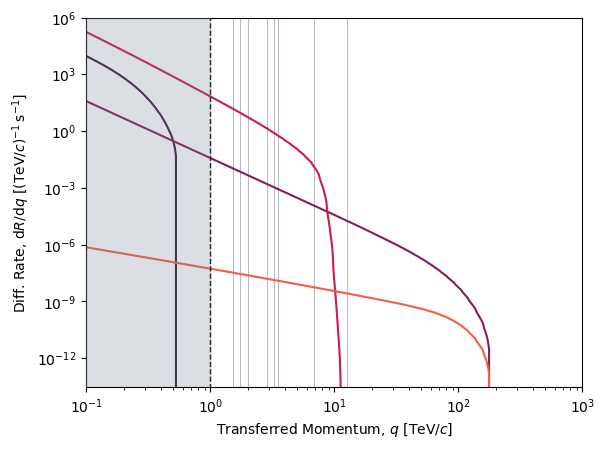

In [37]:
alpha_cand = 0.35
color_cand = '#233C78'
colors = sns.color_palette('rocket', n_colors=len(m_dms)+1)
fig, ax = plt.subplots()

for i in range(len(m_dms)):
    plt.loglog(qs*GEV2TEV, rates_arr[i], color=colors[i])
    
ax.axvspan(1e2*GEV2TEV, 1e3*GEV2TEV, color='slategrey', alpha=0.25, zorder=2.9, lw=1)
ax.vlines(1e3*GEV2TEV, 1e-14, 1e10, color='black', ls='--', lw=1)
ax.set_xlim(1e-1, 1e3)
ax.set_ylim(3e-14, 1e6)
ax.set_yticks(np.logspace(-12, 6, 7))
ax.vlines(cands*GEV2TEV, 1e-14, 1e10, zorder=0.1, alpha=alpha_cand, color=color_cand, lw=0.75)

ax.set_xlabel('Transferred Momentum, $q~[\mathrm{TeV} / c]$')
ax.set_ylabel('Diff. Rate, $\mathrm{d}R / \mathrm{d}q~[(\mathrm{TeV}/c)^{-1}\,\mathrm{s^{-1}}]$')

## $\lambda$ Plot (Fig. 6)

In [26]:
def forward(x):
    x = np.asarray(x, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        return sconstants.hbar / (x * (sconstants.electron_volt / sconstants.c**2) * sconstants.c)

def inverse(x):
    x = np.asarray(x, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        return sconstants.hbar / (x * sconstants.c) / sconstants.electron_volt * sconstants.c**2

SCAN = np.load('../release/luhdm_lambda_scan_v10.npz')
lambs = SCAN['lambda_m_mode1']
alphas = SCAN['alpha_n_mode1']
ps = SCAN['extremeness_mode1']

Text(0, 0.5, 'DM--Neutron Coupling, $\\alpha_n$')

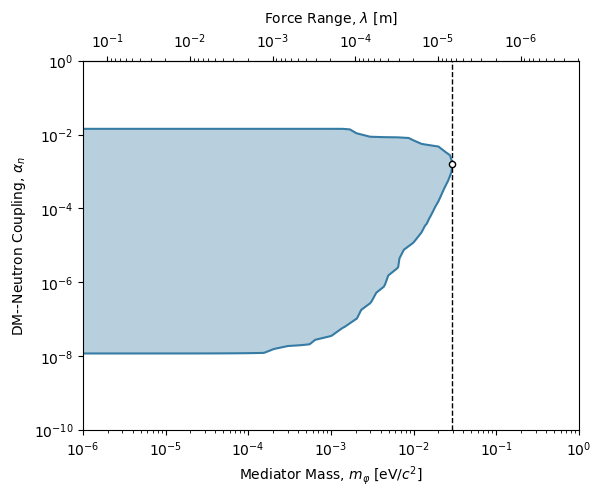

In [27]:
color_lim = sns.color_palette('mako', n_colors=1)[0]
alpha_lim = 0.35

fig, ax = plt.subplots(1, 1)

contour = plt.contour(forward(lambs), alphas, ps, levels=[0.95], colors=color_lim)
plt.contourf(forward(lambs), alphas, ps, levels=[0.95, 1], colors=color_lim, alpha=alpha_lim)
ax.set_xscale('log')
ax.set_yscale('log')



ax.tick_params(which='both', top=False)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.set_xlabel(r'Force Range, $\lambda~[\mathrm{m}]$', labelpad=7)

ax.vlines(0.029559268264403294, 1e-10, 1e0, ls='--', colors=['k'], linewidths=1)
ax.scatter(0.0295592682644032948, 0.0016192068244593688,  marker='o', fc='w', edgecolor='black', s=20, zorder=10)

ax.set_xlim(1e-6, 1e0)
ax.set_xlabel(r'Mediator Mass, $m_{\varphi}~[\mathrm{eV}/c^2]$')
ax.set_ylabel(r'DM--Neutron Coupling, $\alpha_n$')
